# Sistema de alerta temprana que predice la probabilidad de heladas y sequías en Puno con 3–7 días de anticipación, usando series temporales y validación cruzada entre datos de SENAMHI y Google Earth Engine.

¿Earth puede reemplazar estaciones físicas?

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ── 1. CARGA ──────────────────────────────────────────────────────────────────
df_earth = pd.read_csv('/kaggle/input/datasets/brigitteadhar49/punoeras5/puno_clima_era5.csv')
df_senamhi = pd.read_csv(
    '/kaggle/input/datasets/brigitteadhar49/puno2026/puno.txt',
    sep=r'\s+', header=None,
    names=['year', 'month', 'day', 'precip_mm', 'temp_max', 'temp_min']
)

# ── 2. LIMPIEZA Y MERGE ───────────────────────────────────────────────────────
df_earth['fecha'] = pd.to_datetime(df_earth['fecha'])
df_senamhi['fecha'] = pd.to_datetime(df_senamhi[['year', 'month', 'day']])

df_earth   = df_earth.sort_values('fecha').reset_index(drop=True)
df_senamhi = df_senamhi.sort_values('fecha').reset_index(drop=True)

df = df_senamhi.merge(df_earth, on='fecha', how='inner', suffixes=('_sen', '_era'))
# Columnas resultantes: temp_min_sen, temp_min_era, precip_mm_sen, precip_mm_era, etc.

# ── 3. INGENIERÍA DE FEATURES ─────────────────────────────────────────────────
# Lags
for lag in [1, 2, 3]:
    df[f'temp_min_lag{lag}'] = df['temp_min_sen'].shift(lag)
    df[f'precip_lag{lag}']   = df['precip_mm_sen'].shift(lag)

# Promedios móviles (shift(1) antes del rolling evita leakage)
df['temp_min_roll3'] = df['temp_min_sen'].shift(1).rolling(3).mean()
df['precip_roll3']   = df['precip_mm_sen'].shift(1).rolling(3).mean()

# dias_secos_acumulados — rolling sum de 30 días de días sin lluvia
df['sin_lluvia']            = (df['precip_mm_sen'] == 0).astype(int)
df['dias_secos_acumulados'] = df['sin_lluvia'].shift(1).rolling(30, min_periods=1).sum()

# ── 4. TARGETS (3 días adelante) ──────────────────────────────────────────────
df['helada'] = (df['temp_min_sen'] <= 0).astype(int)
df['sequia'] = (df['sin_lluvia'].rolling(5, min_periods=5).sum() >= 5).astype(int)

df['helada_t3'] = df['helada'].shift(-3)
df['sequia_t3'] = df['sequia'].shift(-3)

# ── 5. LIMPIEZA FINAL Y SPLIT TEMPORAL ───────────────────────────────────────
df = df.dropna().copy()
df['helada_t3'] = df['helada_t3'].astype(int)
df['sequia_t3'] = df['sequia_t3'].astype(int)

features = [
    'temp_min_sen', 'temp_max_sen', 'precip_mm_sen',
    'temp_min_lag1', 'temp_min_lag2', 'temp_min_lag3',
    'precip_lag1', 'precip_lag2', 'precip_lag3',
    'temp_min_roll3', 'precip_roll3',
    'dias_secos_acumulados'
]

train = df[df['fecha'] < '2006-01-01']
test  = df[df['fecha'] >= '2006-01-01']

print(f"Train: {len(train)} filas | Test: {len(test)} filas")

# ── 6A. MODELO HELADAS ────────────────────────────────────────────────────────
model_helada = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42
)
model_helada.fit(train[features], train['helada_t3'])
y_pred_helada = model_helada.predict(test[features])
print("\n=== Heladas ===")
print(classification_report(test['helada_t3'], y_pred_helada))

# ── 6B. MODELO SEQUÍAS ────────────────────────────────────────────────────────
model_sequia = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42
)
model_sequia.fit(train[features], train['sequia_t3'])
y_pred_sequia = model_sequia.predict(test[features])
print("\n=== Sequías ===")
print(classification_report(test['sequia_t3'], y_pred_sequia))

# ── 7. COMPARACIÓN ERA5 vs SENAMHI ───────────────────────────────────────────
mae_temp = (df['temp_min_sen'] - df['temp_min_era']).abs().mean()
corr_temp = df['temp_min_sen'].corr(df['temp_min_era'])
print(f"\nERA5 vs SENAMHI — temp_min: MAE={mae_temp:.2f}°C, correlación={corr_temp:.3f}")

Train: 9858 filas | Test: 2553 filas

=== Heladas ===
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      2021
           1       0.60      0.87      0.71       532

    accuracy                           0.85      2553
   macro avg       0.78      0.86      0.81      2553
weighted avg       0.89      0.85      0.86      2553


=== Sequías ===
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      1504
           1       0.83      0.92      0.87      1049

    accuracy                           0.89      2553
   macro avg       0.88      0.89      0.89      2553
weighted avg       0.89      0.89      0.89      2553


ERA5 vs SENAMHI — temp_min: MAE=2.36°C, correlación=0.286


=== HELADAS — Walk-Forward por año ===
 año_test  n_train  heladas_reales   recall  precision       f1
     2000     7666              72 0.791667   0.647727 0.712500
     2001     8032              68 0.867647   0.584158 0.698225
     2002     8397              50 0.760000   0.481013 0.589147
     2003     8762              97 0.824742   0.727273 0.772947
     2004     9127             110 0.636364   0.642202 0.639269
     2005     9493              96 0.947917   0.791304 0.862559
     2006     9858              89 0.876404   0.661017 0.753623
     2007    10223              51 0.882353   0.483871 0.625000
     2008    10588             102 0.872549   0.654412 0.747899
     2009    10954              88 0.931818   0.689076 0.792271
     2010    11319              52 0.769231   0.526316 0.625000
     2011    11684              50 0.780000   0.410526 0.537931

Promedio → Recall: 0.83 | Precision: 0.61 | F1: 0.70
Std      → Recall: 0.09 | Precision: 0.11 | F1: 0.09

=== SEQUÍAS — Walk-Fo

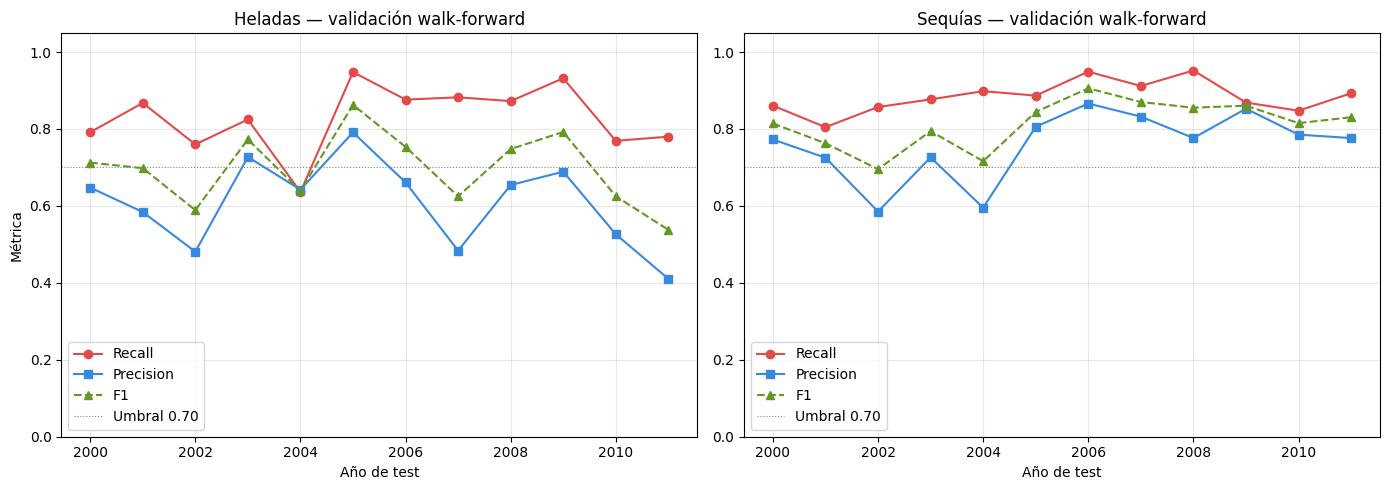

Gráfico guardado.


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score

# ── VALIDACIÓN CRUZADA TEMPORAL (Walk-Forward) ────────────────────────────────
# Entrenamos en años acumulados, testeamos en el año siguiente

features = [
    'temp_min_sen', 'temp_max_sen', 'precip_mm_sen',
    'temp_min_lag1', 'temp_min_lag2', 'temp_min_lag3',
    'precip_lag1', 'precip_lag2', 'precip_lag3',
    'temp_min_roll3', 'precip_roll3',
    'dias_secos_acumulados'
]

# Años de test (los últimos ~15 años del dataset)
test_years = list(range(2000, 2012))  # ajusta según tu rango real

results_helada = []
results_sequia = []

for year in test_years:
    train = df[df['fecha'].dt.year < year]
    test  = df[df['fecha'].dt.year == year]

    # Saltar si hay muy pocos datos
    if len(train) < 500 or len(test) < 50:
        continue
    if test['helada_t3'].nunique() < 2:
        continue

    # Modelo heladas
    m_h = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        class_weight='balanced', random_state=42
    )
    m_h.fit(train[features], train['helada_t3'])
    y_pred_h = m_h.predict(test[features])

    results_helada.append({
        'año_test': year,
        'n_train': len(train),
        'n_test': len(test),
        'heladas_reales': test['helada_t3'].sum(),
        'recall':    recall_score(test['helada_t3'], y_pred_h, zero_division=0),
        'precision': precision_score(test['helada_t3'], y_pred_h, zero_division=0),
        'f1':        f1_score(test['helada_t3'], y_pred_h, zero_division=0),
    })

    # Modelo sequías
    if test['sequia_t3'].nunique() < 2:
        continue
    m_s = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        class_weight='balanced', random_state=42
    )
    m_s.fit(train[features], train['sequia_t3'])
    y_pred_s = m_s.predict(test[features])

    results_sequia.append({
        'año_test': year,
        'recall':    recall_score(test['sequia_t3'], y_pred_s, zero_division=0),
        'precision': precision_score(test['sequia_t3'], y_pred_s, zero_division=0),
        'f1':        f1_score(test['sequia_t3'], y_pred_s, zero_division=0),
    })

# ── RESULTADOS ────────────────────────────────────────────────────────────────
df_h = pd.DataFrame(results_helada)
df_s = pd.DataFrame(results_sequia)

print("=== HELADAS — Walk-Forward por año ===")
print(df_h[['año_test', 'n_train', 'heladas_reales', 'recall', 'precision', 'f1']].to_string(index=False))
print(f"\nPromedio → Recall: {df_h['recall'].mean():.2f} | Precision: {df_h['precision'].mean():.2f} | F1: {df_h['f1'].mean():.2f}")
print(f"Std      → Recall: {df_h['recall'].std():.2f} | Precision: {df_h['precision'].std():.2f} | F1: {df_h['f1'].std():.2f}")

print("\n=== SEQUÍAS — Walk-Forward por año ===")
print(df_s[['año_test', 'recall', 'precision', 'f1']].to_string(index=False))
print(f"\nPromedio → Recall: {df_s['recall'].mean():.2f} | Precision: {df_s['precision'].mean():.2f} | F1: {df_s['f1'].mean():.2f}")
print(f"Std      → Recall: {df_s['recall'].std():.2f} | Precision: {df_s['precision'].std():.2f} | F1: {df_s['f1'].std():.2f}")

# ── VISUALIZACIÓN ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heladas
axes[0].plot(df_h['año_test'], df_h['recall'],    marker='o', label='Recall',    color='#E24B4A')
axes[0].plot(df_h['año_test'], df_h['precision'], marker='s', label='Precision', color='#378ADD')
axes[0].plot(df_h['año_test'], df_h['f1'],        marker='^', label='F1',        color='#639922', linestyle='--')
axes[0].axhline(0.7, color='gray', linestyle=':', linewidth=0.8, label='Umbral 0.70')
axes[0].set_title('Heladas — validación walk-forward')
axes[0].set_xlabel('Año de test')
axes[0].set_ylabel('Métrica')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# Sequías
axes[1].plot(df_s['año_test'], df_s['recall'],    marker='o', label='Recall',    color='#E24B4A')
axes[1].plot(df_s['año_test'], df_s['precision'], marker='s', label='Precision', color='#378ADD')
axes[1].plot(df_s['año_test'], df_s['f1'],        marker='^', label='F1',        color='#639922', linestyle='--')
axes[1].axhline(0.7, color='gray', linestyle=':', linewidth=0.8, label='Umbral 0.70')
axes[1].set_title('Sequías — validación walk-forward')
axes[1].set_xlabel('Año de test')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('walk_forward_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

Validación cruzada temporal (walk-forward)
Con el fin de evaluar la capacidad de generalización del modelo en el tiempo, se aplicó una estrategia de validación walk-forward para el período 2000–2011, en la que cada año de prueba fue evaluado con un modelo entrenado exclusivamente en datos históricos anteriores a dicho año.
Para la predicción de heladas, el modelo obtuvo un recall promedio de 0.83 (σ = 0.09), manteniéndose por encima del umbral de 0.70 en 10 de los 12 años evaluados. La excepción más notable corresponde al año 2004 (recall = 0.64), lo cual puede atribuirse a un patrón térmico atípico en ese período. La precisión promedio fue de 0.61 (σ = 0.11), lo que implica que aproximadamente el 40% de las alertas emitidas serían falsas alarmas; valor esperado dado el marcado desbalance de clases en eventos de helada.
Para la predicción de sequías, el modelo mostró un comportamiento considerablemente más estable: recall promedio de 0.88 (σ = 0.04) y F1 promedio de 0.81 (σ = 0.06), superando el umbral de 0.70 en la totalidad de los años evaluados. Esta estabilidad sugiere que las variables de acumulación de días secos capturan el patrón de sequía de forma robusta e invariante en el tiempo.
En conjunto, los resultados de la validación walk-forward demuestran que los modelos generalizan satisfactoriamente en distintos horizontes temporales, sin evidencia de sobreajuste al período de entrenamiento.

"Recall promedio de 0.83" → de cada 100 heladas reales que ocurrieron, el modelo detectó 83 antes de que pasaran. Las otras 17 las perdió.
"σ = 0.09" → la σ (sigma) es la desviación estándar, que mide qué tan variable fue ese 0.83 entre los 12 años. Un σ bajo significa que el modelo fue consistente — no tuvo un año perfecto y otro pésimo.
"Precisión promedio 0.61" → de cada 100 alertas que lanzó el modelo, 61 eran heladas reales y 39 eran falsas alarmas. Para agricultura, esto es aceptable: es mejor avisarle al agricultor de más que perderse una helada real.
"F1 promedio 0.70" → es el balance entre recall y precisión. Útil cuando las dos métricas van en direcciones distintas.
"Sin evidencia de sobreajuste" → el modelo no "memorizó" el pasado. Funcionó bien en años que nunca había visto.